# <div style="padding:20px;color:white;margin:0;font-size:35px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden"><b><center>Image Analysis and Computer Vision </center></b>
<h2 style="font-family: Verdana; font-size: 25px; font-style: normal; font-weight: normal; text-decoration: none; text-transform: none; letter-spacing: 2px; color: #155D07; background-color: #ffffff;"><b>Project</b> </div>
<ul>
	<li><span style='font-size:15px; font-family:Verdana;color: #254E58;'><b>Anesu Muponda</b></span></li>
	<li><span style='font-size:15px; font-family:Verdana;color: #254E58;'><b>R204577N</b></span></li>
	<li><span style='font-size:15px; font-family:Verdana;color: #254E58;'><b>HDS</b></span></li>
	<li><span style='font-size:15px; font-family:Verdana;color: #254E58;'><b>Image Analysis and Computer Vision	</b></span></li>


<div style="padding:20px;color:white;margin:0;font-size:35px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden"><b><center>Importing Necessary files</center></b>

In [1]:
import os
import re
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D


<div style="padding:20px;color:white;margin:0;font-size:35px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden"><b><center>Objectives of the CNN Algorithm</center></b>

The objective of this project is solve a Classification problem.The diagnosis of blood-based diseases often involves identifying and characterizing patient blood samples hence automated methods to detect and classify blood cell subtypes have important medical applications.The Algorithm employed should be able to detect and classify the blood cell into either Eosinophil or Lymphocyte however the project can be developed to classify other blood cell subtypes which is not the primary focus of this project.

<div style="padding:20px;color:white;margin:0;font-size:35px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden"><b><center>Exploratory Data Analysis</center></b>

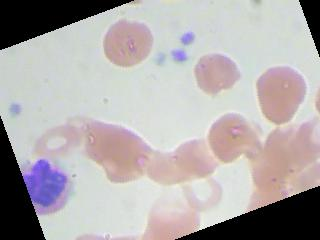

In [4]:
# EOSINOPHI Blood cell type
from PIL import Image
%matplotlib inline
# Import an image
EOSINOPHI= Image.open('bloodcells/EOSINOPHIL/_0_187.jpeg')
EOSINOPHI

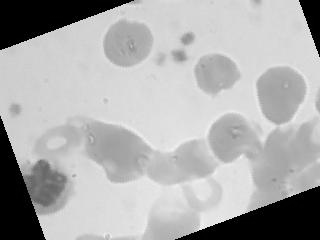

In [5]:
# convert into grey-scale
im= EOSINOPHI.convert('L')
im

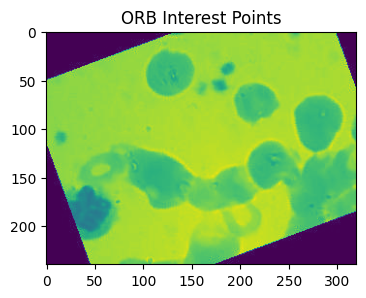

In [6]:
# draw circles 
plt.figure(figsize=(4,4))
plt.title('ORB Interest Points')
plt.imshow(im); plt.show()

### LYMPHOCYTE Blood cell type


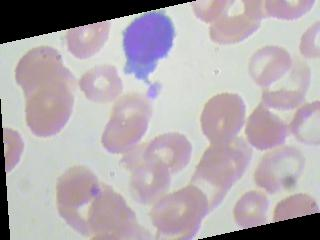

In [8]:
# LYMPHOCYTE blood cell type
from PIL import Image
%matplotlib inline
# Import an image
image2 = Image.open('bloodcells/LYMPHOCYTE/_0_33.jpeg')
image2

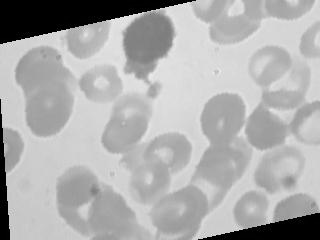

In [9]:
# convert into grey-scale
im2 = image2.convert('L')
im2

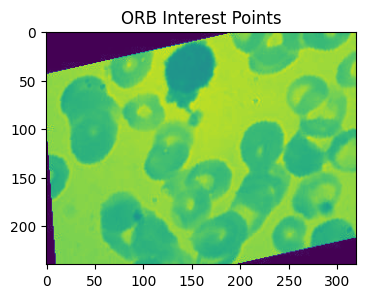

In [10]:
# draw circles 
plt.figure(figsize=(4,4))
plt.title('ORB Interest Points')
plt.imshow(im2); plt.show()


<div style="padding:20px;color:white;margin:0;font-size:35px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden"><b><center>Importing the Keras libraries and packages</center></b>

In [11]:
import numpy as np
# from kras.preprocessing import image
import tensorflow as tf

In [12]:
# Initializing the CNN
model = tf.keras.models.Sequential()

In [13]:
# Layer 2 - Pooling
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2),strides=(1, 1), padding='valid'))

In [14]:
# Layer 1 - Convolution with non linearity
model.add(tf.keras.layers.Conv2D(64, (3,3), input_shape=(64, 64, 3), activation='relu'))

In [15]:
# adding another convolutional layer
model.add(tf.keras.layers.Conv2D(32, (3,3), activation='relu'))

In [16]:
# adding pooling layer
model.add(tf.keras.layers.MaxPooling2D(pool_size = (2, 2),strides=(1, 1), padding='valid'))

In [17]:
# Layer 3 - Flattening
model.add(tf.keras.layers.Flatten())

In [18]:
# Layer 4 - Fully connected layer
model.add(tf.keras.layers.Dense(units = 128, activation = 'relu')) #'relu'
model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(units = 128, activation = 'relu')) #'relu'
model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(units = 128, activation = 'relu')) #'relu'
model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(units = 1, activation = 'sigmoid'))

In [19]:
# Compiling the CNN
model.compile(optimizer = tf.keras.optimizers.SGD(learning_rate=0.0001, momentum=0.9), loss = 'binary_crossentropy', metrics = ['accuracy'])

In [20]:
# Define constants
IMG_WIDTH = 224
IMG_HEIGHT = 224
IMG_CHANNELS = 3
TRAIN_TEST_SPLIT = 0.2
EPOCHS = 10
BATCH_SIZE = 32
LEARNING_RATE = 0.001

In [21]:
# Define data loading and preprocessing functions
def load_data(data_dir):
    data = []
    labels = []

    for class_name in ['EOSINOPHIL', 'LYMPHOCYTE']:
        class_dir = os.path.join(data_dir, class_name)
        files = os.listdir(class_dir)

        for file in files:
            img_path = os.path.join(class_dir, file)
            img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_WIDTH, IMG_HEIGHT))
            img_array = tf.keras.preprocessing.image.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)
            img_array = img_array / 255.0

            data.append(img_array)
            labels.append(class_name)

    data = np.vstack(data)
    labels = np.array(labels)

    return data, labels

In [37]:
def preprocess_data(data, labels, train_test_split):
    x_train, x_test, y_train, y_test = train_test_split(data, labels, test_size=train_test_split, random_state=42)

    return x_train, y_train, x_test, y_test

In [22]:
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

data_dir = 'bloodcells'
data, labels = load_data(data_dir)

# Shuffle the data
data, labels = shuffle(data, labels, random_state=10)

# Split the data into training and testing sets
train_images, test_images, train_labels, test_labels = train_test_split(data, labels, test_size = 0.2)

# Split the test data into validation and test sets
test_images, val_images, test_labels, val_labels = train_test_split(test_images, test_labels, test_size = 0.5)

In [23]:
n_train = train_labels.shape[0]
n_val = val_labels.shape[0]
n_test = test_labels.shape[0]

print("Number of training examples: {}".format(n_train))
print("Number of validation examples: {}".format(n_val))
print("Number of testing examples: {}".format(n_test))

print("Training images are of shape: {}".format(train_images.shape))
print("Training labels are of shape: {}".format(train_labels.shape))
print("Validation images are of shape: {}".format(val_images.shape))
print("Validation labels are of shape: {}".format(val_labels.shape))
print("Test images are of shape: {}".format(test_images.shape))
print("Test labels are of shape: {}".format(test_labels.shape))

Number of training examples: 994
Number of validation examples: 125
Number of testing examples: 124
Training images are of shape: (994, 224, 224, 3)
Training labels are of shape: (994,)
Validation images are of shape: (125, 224, 224, 3)
Validation labels are of shape: (125,)
Test images are of shape: (124, 224, 224, 3)
Test labels are of shape: (124,)


In [24]:
train_images = train_images / 255.0 
val_images = val_images / 255.0
test_images = test_images / 255.0

In [29]:
# Resize the training images to match the expected input shape
train_images = tf.image.resize(train_images, [120, 120])

In [32]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.layers import Conv2D, MaxPooling2D, Dropout
import warnings 
warnings.filterwarnings('ignore')


model1 = Sequential()

# First Conv Layer
model1.add(Conv2D(16 , (3,3) , activation = 'relu' , input_shape = (120,120,3)))
model1.add(MaxPooling2D(pool_size = (2,2)))

# Second Conv Layer
model1.add(Conv2D(32, (3,3), activation = 'relu'))
model1.add(MaxPooling2D(pool_size = (2,2)))
model1.add(Dropout(0.25))

# Third Conv Layer
model1.add(Conv2D(64, (3,3), activation = 'relu'))
model1.add(MaxPooling2D(pool_size = (2,2)))
model1.add(Dropout(0.25))

# FC layer
model1.add(Flatten())
model1.add(Dense(units = 128 , activation = 'relu'))
model1.add(Dropout(0.25))

# Output layer
model1.add(Dense(units = 4 , activation = 'softmax'))

# Compile
model1.compile(optimizer = "adam" , loss = 'sparse_categorical_crossentropy' , metrics = ['accuracy'])
model1.summary()
# train
history1 = model1.fit(
    train_images, 
    train_labels, 
    batch_size = 32, 
    epochs = 10, 
    validation_data=(val_images, val_labels))


Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_11 (Conv2D)          (None, 118, 118, 16)      448       
                                                                 
 max_pooling2d_10 (MaxPoolin  (None, 59, 59, 16)       0         
 g2D)                                                            
                                                                 
 conv2d_12 (Conv2D)          (None, 57, 57, 32)        4640      
                                                                 
 max_pooling2d_11 (MaxPoolin  (None, 28, 28, 32)       0         
 g2D)                                                            
                                                                 
 dropout_9 (Dropout)         (None, 28, 28, 32)        0         
                                                                 
 conv2d_13 (Conv2D)          (None, 26, 26, 64)       

UnimplementedError: Graph execution error:

Detected at node 'Cast_1' defined at (most recent call last):
    File "C:\Users\DELL\anaconda3\envs\newtf\lib\runpy.py", line 197, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "C:\Users\DELL\anaconda3\envs\newtf\lib\runpy.py", line 87, in _run_code
      exec(code, run_globals)
    File "C:\Users\DELL\anaconda3\envs\newtf\lib\site-packages\ipykernel_launcher.py", line 17, in <module>
      app.launch_new_instance()
    File "C:\Users\DELL\anaconda3\envs\newtf\lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
      app.start()
    File "C:\Users\DELL\anaconda3\envs\newtf\lib\site-packages\ipykernel\kernelapp.py", line 701, in start
      self.io_loop.start()
    File "C:\Users\DELL\anaconda3\envs\newtf\lib\site-packages\tornado\platform\asyncio.py", line 195, in start
      self.asyncio_loop.run_forever()
    File "C:\Users\DELL\anaconda3\envs\newtf\lib\asyncio\windows_events.

In [33]:
# Fitting the CNN to the images
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale = 1./255,
                                                                shear_range = 0.2,
                                                                zoom_range = 0.2,
                                                                horizontal_flip = True)

In [34]:
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale = 1./255)

In [35]:
training_set = train_datagen.flow_from_directory('bloodcells',
                                                 target_size = (64, 64),
                                                 batch_size = 3,
                                                 class_mode = 'binary')

Found 1243 images belonging to 2 classes.


In [36]:
test_set = test_datagen.flow_from_directory('bloodcells',
                                            target_size = (64, 64),
                                            batch_size = 3,
                                            class_mode = 'binary')

Found 1243 images belonging to 2 classes.


---

In [37]:
# Save the model according to the conditions  
checkpoint = tf.keras.callbacks.ModelCheckpoint("bloodcells.keras", monitor='val_acc', verbose=1, save_best_only=True, save_weights_only=False, mode='auto', save_freq=1)
early = tf.keras.callbacks.EarlyStopping(monitor='val_acc', min_delta=0, patience=10, verbose=1, mode='auto')

In [38]:
import warnings 
warnings.filterwarnings('ignore')

# fitting the model
model.fit(training_set,
                    steps_per_epoch = 100,
                    epochs = 20,
                    verbose=1,
                    validation_data = test_set,
                    #callbacks = [checkpoint, early, tensorboard],
                    validation_steps = 200)

Epoch 1/20
100/100 [==============================] - 12s 106ms/step - loss: 0.6965 - accuracy: 0.4564 - val_loss: 0.6935 - val_accuracy: 0.4950
Epoch 2/20
100/100 [==============================] - 12s 123ms/step - loss: 0.6955 - accuracy: 0.4933 - val_loss: 0.6944 - val_accuracy: 0.5067
Epoch 3/20
100/100 [==============================] - 12s 123ms/step - loss: 0.6955 - accuracy: 0.4664 - val_loss: 0.6917 - val_accuracy: 0.5250
Epoch 4/20
100/100 [==============================] - 14s 135ms/step - loss: 0.6954 - accuracy: 0.4900 - val_loss: 0.6932 - val_accuracy: 0.4917
Epoch 5/20
100/100 [==============================] - 13s 129ms/step - loss: 0.6886 - accuracy: 0.5134 - val_loss: 0.6934 - val_accuracy: 0.4883
Epoch 6/20
100/100 [==============================] - 12s 115ms/step - loss: 0.6952 - accuracy: 0.5200 - val_loss: 0.6934 - val_accuracy: 0.4967
Epoch 7/20
100/100 [==============================] - 11s 110ms/step - loss: 0.6947 - accuracy: 0.5167 - val_loss: 0.6929 - val_ac


<div style="padding:20px;color:white;margin:0;font-size:35px;font-family:Georgia;text-align:left;display:fill;border-radius:5px;background-color:#254E58;overflow:hidden"><b><center>Analytics Outcome</center></b>


In [39]:
# Load an image to predict
test_image = tf.keras.preprocessing.image.load_img('bloodcells/_0_33.jpeg', target_size = (64, 64))
test_image = tf.keras.preprocessing.image.img_to_array(test_image)
test_image = np.expand_dims(test_image, axis = 0)
result =model.predict(test_image)

if result[0][0] == 1:
    prediction = 'EOSINOPHIL'
else:
    prediction = 'LYMPHOCYTE' 

1/1 [==============================] - 0s 206ms/step


In [40]:
print(prediction)

LYMPHOCYTE
